<a href="https://colab.research.google.com/github/harshchaudhary11/Machine-Learning/blob/main/Share_Price_Forecasting_using_Facebook_Prophet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install prophet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import prophet as fbp
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [ ]:
data = pd.read_csv("/content/Share-Price-Forecasting-Using-Facebook-Prophet---Dataset.csv")
data.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
2134,2023-07-20,134.070007,134.789993,129.330002,129.960007,129.960007,59820600
2135,2023-07-21,131.339996,131.369995,128.419998,130.000000,130.000000,133265000
2136,2023-07-24,130.309998,131.660004,128.350006,128.800003,128.800003,45591100
2137,2023-07-25,129.309998,129.580002,128.529999,129.130005,129.130005,39236700
2138,2023-07-26,126.510002,129.080002,126.110001,128.149994,128.149994,53910100


In [ ]:
if "Date" in data.columns and "Adj Close" in data.columns:
    data = data.rename(columns={"Date": "ds", "Adj Close": "y"})
    data = data[["ds", "y"]]
elif "ds" in data.columns and "y" in data.columns:
    # Data is already transformed, ensure only these columns are present.
    data = data[["ds", "y"]]
else:
    raise KeyError("Required columns 'Date' and 'Adj Close' (or 'ds' and 'y') not found in DataFrame.")
data


,ds,y
0,2015-01-27,15.337500
1,2015-01-28,15.195500
2,2015-01-29,15.589000
3,2015-01-30,17.726500
4,2015-02-02,18.223499
...,...,...
2134,2023-07-20,129.960007
2135,2023-07-21,130.000000
2136,2023-07-24,128.800003
2137,2023-07-25,129.130005


In [ ]:
split_data = "2019-07-21"
data_train = data.loc[data.ds <= split_data].copy()
data.test = data.loc[data.ds > split_data].copy()

In [ ]:
model = fbp.Prophet()
model.fit(data_train)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
from prophet import forecaster
forecast = model.predict(data.test)
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
1006,2023-07-20,108.893275,-108.617872,339.205106,-116.534435,333.759659,7.124708,7.124708,7.124708,1.287959,1.287959,1.287959,5.836749,5.836749,5.836749,0.0,0.0,0.0,116.017982
1007,2023-07-21,108.906229,-108.617069,339.194547,-116.932740,334.164447,7.006895,7.006895,7.006895,1.132720,1.132720,1.132720,5.874174,5.874174,5.874174,0.0,0.0,0.0,115.913124
1008,2023-07-24,108.945092,-110.540045,341.700676,-117.305137,334.433808,6.951290,6.951290,6.951290,1.053089,1.053089,1.053089,5.898201,5.898201,5.898201,0.0,0.0,0.0,115.896382
1009,2023-07-25,108.958047,-111.179413,341.461377,-117.703443,334.677261,7.161560,7.161560,7.161560,1.282641,1.282641,1.282641,5.878919,5.878919,5.878919,0.0,0.0,0.0,116.119606
1010,2023-07-26,108.971001,-111.343711,343.605497,-118.101749,334.920713,7.144080,7.144080,7.144080,1.296338,1.296338,1.296338,5.847742,5.847742,5.847742,0.0,0.0,0.0,116.115081


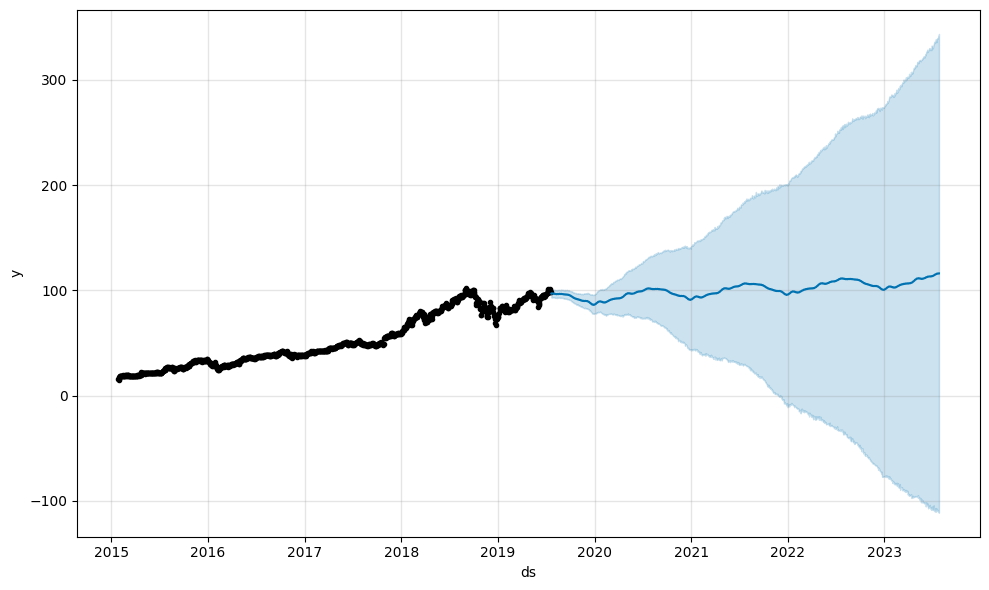

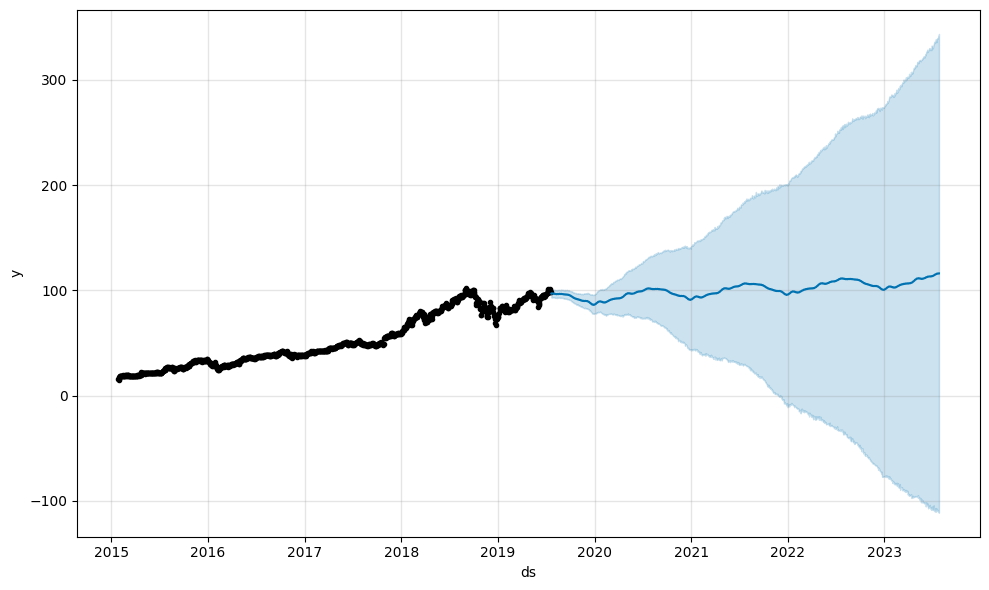

In [ ]:
model.plot(forecast)

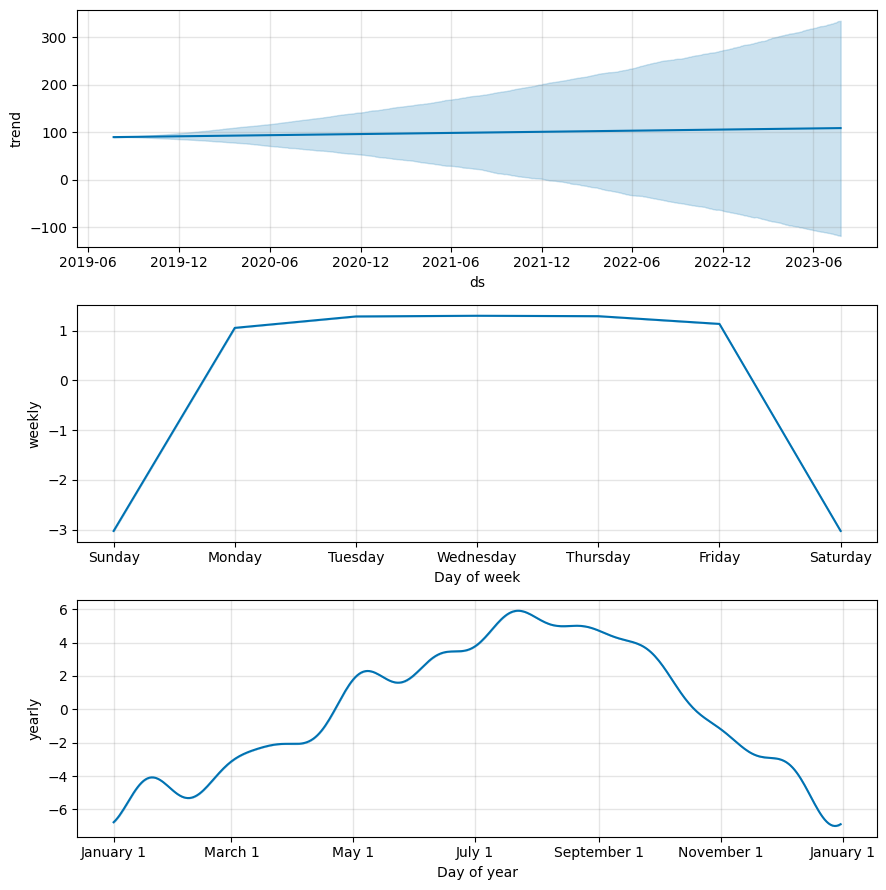

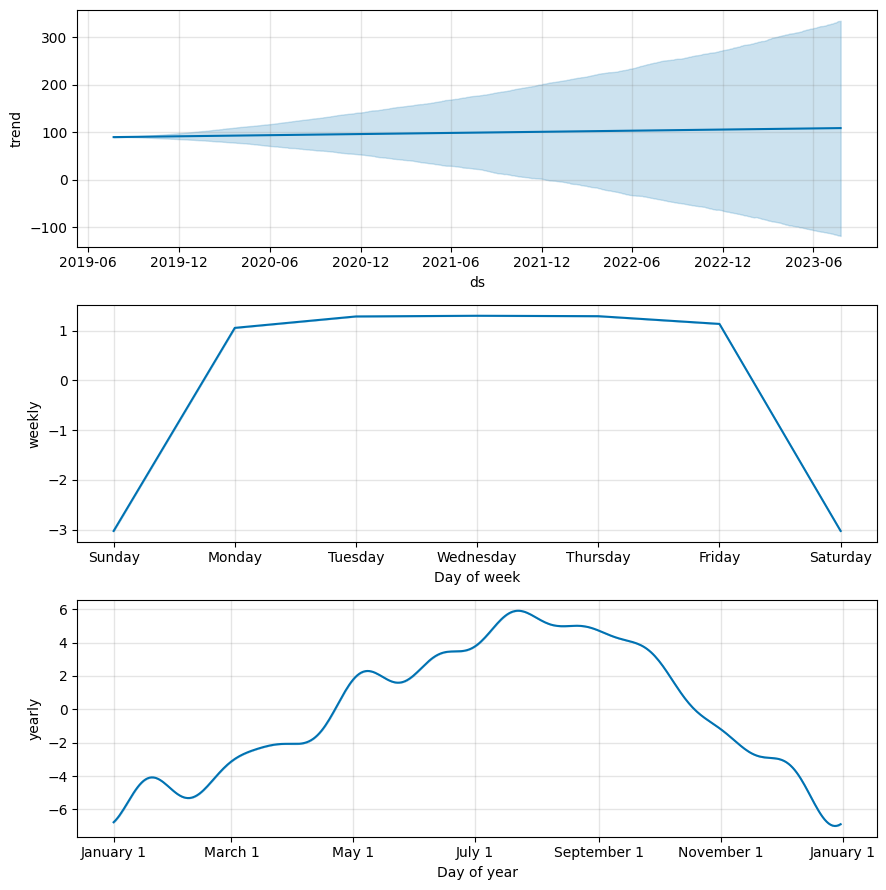

In [ ]:
model.plot_components(forecast)

In [ ]:
print("Mean Squar Error(MSE):",mean_squared_error(y_true=data.test["y"],y_pred=forecast.yhat))
print("Mean Absolute Error(MAE):",mean_absolute_error(y_true=data.test["y"],y_pred=forecast["yhat"]))

Mean Squar Error(MSE): 1928.6083835142474
Mean Absolute Error(MAE): 34.278188985030724
